# Practice exam

### Importing the libraries

In [4]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error

### Loading the data

In [5]:
data = pd.read_csv('Hitters-fs.csv')
df = data.copy()
df

,AtBat,Hits,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Salary
0,315,81,39,3449,835,69,321,414,375,632,475.0
1,479,130,76,1624,457,63,224,266,263,880,480.0
2,496,141,37,5628,1575,225,828,838,354,200,500.0
3,321,87,30,396,101,12,48,46,33,805,91.5
4,594,169,35,4408,1133,19,501,336,194,282,750.0
...,...,...,...,...,...,...,...,...,...,...,...
258,497,127,37,2703,806,32,379,311,138,325,700.0
259,492,136,94,5511,1511,39,897,451,875,313,875.0
260,475,126,52,1700,433,7,217,93,146,37,385.0
261,573,144,78,3198,857,97,470,420,332,1314,960.0


In [6]:
df.columns

Index(['AtBat', 'Hits', 'Walks', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI',
       'CWalks', 'PutOuts', 'Salary'],
      dtype='object')

In [7]:
df.isnull().sum()

AtBat      0
Hits       0
Walks      0
CAtBat     0
CHits      0
CHmRun     0
CRuns      0
CRBI       0
CWalks     0
PutOuts    0
Salary     0
dtype: int64

In [8]:
correlation = df.corr()
correlation['Salary'].sort_values(ascending=True)

PutOuts    0.300480
AtBat      0.394771
Hits       0.438675
Walks      0.443867
CWalks     0.489822
CHmRun     0.524931
CAtBat     0.526135
CHits      0.548910
CRuns      0.562678
CRBI       0.566966
Salary     1.000000
Name: Salary, dtype: float64

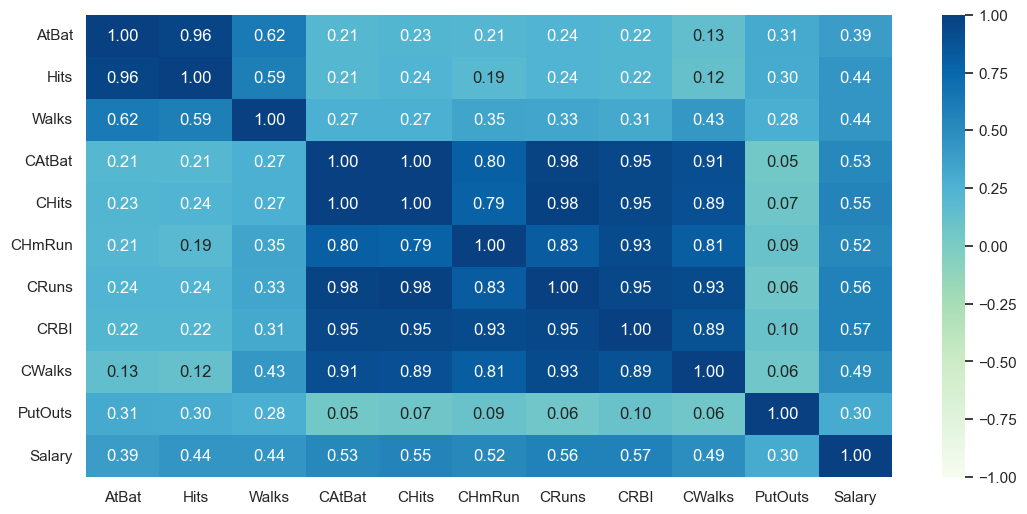

In [9]:
# Check for multicolinearity


plt.figure(figsize=(13,6))
sns.heatmap(
    correlation,
    vmin=-1,
    vmax=1,
    cmap="GnBu",
    annot=True,
    fmt=".2f"
)
plt.show()

### Defining the X and the y variables and split the data into train and test sets using standardized values 

In [10]:
X = df.drop('Salary', axis = 1)
y = df['Salary']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=365)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) 

### Enter your code below

In [11]:
lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
print('Coefficients: \n', lin_reg.coef_)
print('Intercept: \n', lin_reg.intercept_)

Coefficients: 
 [-209.29031637  200.14361436   87.10197979 -875.47484675  790.71979606
   16.39785005  357.0970638    56.84082885 -124.96836551  120.00801084]
Intercept: 
 532.2961176470588


In [14]:
lin_reg_y_pred = lin_reg.predict(x_test)

In [15]:
data_predicted = pd.DataFrame({'Actual': y_test, 'Predicted': lin_reg_y_pred})
data_predicted.head()

,Actual,Predicted
13,240.0,337.546332
141,737.5,529.824347
137,1300.0,687.261146
94,737.5,752.346802
224,475.0,454.246326


In [17]:
print('LinearRegression Model RMSE is :',math.sqrt(mean_squared_error(y_test,lin_reg_y_pred)) )
print("Linear Regression Training Score is :", lin_reg.score(x_train, y_train))
print("Linear Regression Testing Score is :", lin_reg.score(x_test, y_test))

LinearRegression Model RMSE is : 301.51617214402535
Linear Regression Training Score is : 0.5216785712968777
Linear Regression Testing Score is : 0.39366641684289005


## Ridge Lasso

In [18]:
cv = RepeatedKFold(n_splits = 5, n_repeats=3, random_state=365)
ridge = RidgeCV(alphas=np.arange(0.1, 10, 0.1), cv=cv , scoring = "neg_mean_squared_error")


In [19]:
ridge.fit(x_train, y_train)
ridge_y_pred = ridge.predict(x_test)

In [20]:
print("turning parameter is :", (ridge.alpha_))
print("ridge model coefficients are : ", ridge.coef_)
print( "Ridge intercept", ridge.intercept_)


turning parameter is : 0.5
ridge model coefficients are :  [-233.00251426  228.68773108   94.91852277 -471.98700532  319.13132316
  -32.1909439   404.6646816   157.68282661 -169.18278455  123.10619334]
Ridge intercept 532.2961176470588


In [21]:
print('Ridge Model RMSE is :',math.sqrt(mean_squared_error(y_test,ridge_y_pred)) )
print("Ridge Regression Model Training Score: ",ridge.score(x_train, y_train))
print("Ridge Regression Model Testing Score: ",ridge.score(x_test, y_test))

Ridge Model RMSE is : 286.7208431469446
Ridge Regression Model Training Score:  0.5180771081394934
Ridge Regression Model Testing Score:  0.45171175926775775


## Lasso

In [22]:
# Initializing the lasso regressor
lasso = LassoCV(alphas=np.arange(0.1, 10.0, 0.1), cv=cv, tol = 1)

In [23]:
# Fitting the lasso regressor
lasso.fit(x_train,y_train)
lasso_reg_y_pred = lasso.predict(x_test)

print("Lasso tuning parameter:", (lasso.alpha_))
print ("Lasso model coefficients:", (lasso.coef_))
print ("Lassso model intercept:", (lasso.intercept_))

Lasso tuning parameter: 0.1
Lasso model coefficients: [ 35.98164565  50.65538287  66.9826693  198.74142951  21.35532169
  28.19516389 -21.94717264  16.0421075  -41.4070888  121.22091612]
Lassso model intercept: 532.2961176470588


In [24]:
print("Lasso Regression Model RMSE is: ", math.sqrt(mean_squared_error(y_test, lasso_reg_y_pred)))
print("Lasso Regression Model Training Score: ",lasso.score(x_train, y_train))
print("Lasso Regression Model Testing Score: ",lasso.score(x_test, y_test))

Lasso Regression Model RMSE is:  294.3112778516602
Lasso Regression Model Training Score:  0.43611579410472534
Lasso Regression Model Testing Score:  0.4222975490396823


## COMPARISON

In [25]:
print("Linear Regression Model Training Score: ",lin_reg.score(x_train, y_train))
print("Linear Regression Model Testing Score: ",lin_reg.score(x_test, y_test))
print("Ridge Regression Model Training Score: ",ridge.score(x_train, y_train))
print("Ridge Regression Model Testing Score: ",ridge.score(x_test, y_test))
print("Lasso Regression Model Training Score: ",lasso.score(x_train, y_train))
print("Lasso Regression Model Testing Score: ",lasso.score(x_test, y_test))

Linear Regression Model Training Score:  0.5216785712968777
Linear Regression Model Testing Score:  0.39366641684289005
Ridge Regression Model Training Score:  0.5180771081394934
Ridge Regression Model Testing Score:  0.45171175926775775
Lasso Regression Model Training Score:  0.43611579410472534
Lasso Regression Model Testing Score:  0.4222975490396823


## Root mean Squarred Error

In [26]:
print("Linear Regression Model RMSE is: ", math.sqrt(mean_squared_error(y_test, lin_reg_y_pred)))
print("Ridge Regression Model RMSE is: ", math.sqrt(mean_squared_error(y_test, ridge_y_pred)))
print("Lasso Regression Model RMSE is: ", math.sqrt(mean_squared_error(y_test, lasso_reg_y_pred)))

Linear Regression Model RMSE is:  301.51617214402535
Ridge Regression Model RMSE is:  286.7208431469446
Lasso Regression Model RMSE is:  294.3112778516602
